# 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)


# 2. Final model results
We put the final model scores in one table.


In [2]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "K-Nearest Neighbours",
        "Decision Tree",
        "Gradient Boosting",
        "Random Forest"
    ],
    "Model Type": [
        "Linear baseline",
        "Probabilistic baseline",
        "Distance-based classifier",
        "Interpretable tree-based model",
        "Boosted tree ensemble",
        "Bagged tree ensemble"
    ],
    "Threshold": [
        0.50,
        0.50,
        0.93,
        0.99,
        0.94,
        0.50
    ],
    "Accuracy": [
        0.9337,
        0.9687,
        0.9950,
        0.9998,
        0.9999,
        0.9999
    ],
    "Fraud Precision": [
        0.0144,
        0.0133,
        0.1271,
        0.9130,
        1.0000,
        1.0000
    ],
    "Fraud Recall": [
        0.7391,
        0.3152,
        0.4891,
        0.9130,
        0.9022,
        0.9130
    ],
    "Fraud F1-score": [
        0.0282,
        0.0256,
        0.2018,
        0.9130,
        0.9486,
        0.9545
    ],
    "ROC-AUC": [
        0.9238,
        0.8458,
        0.9036,
        0.9783,
        0.9798,
        0.9900
    ],
    "PR-AUC": [
        0.2337,
        0.0149,
        0.0822,
        0.9272,
        0.9319,
        0.9358
    ]
})

results["Recommendation"] = [
    "Baseline only; too many false positives",
    "Not recommended",
    "Not recommended",
    "Useful interpretable alternative",
    "Strong challenger model",
    "Recommended main model"
]

results


,Model,Model Type,Threshold,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-score,ROC-AUC,PR-AUC,Recommendation
0,Logistic Regression,Linear baseline,0.50,0.9337,0.0144,0.7391,0.0282,0.9238,0.2337,Baseline only; too many false positives
1,Naive Bayes,Probabilistic baseline,0.50,0.9687,0.0133,0.3152,0.0256,0.8458,0.0149,Not recommended
2,K-Nearest Neighbours,Distance-based classifier,0.93,0.9950,0.1271,0.4891,0.2018,0.9036,0.0822,Not recommended
3,Decision Tree,Interpretable tree-based model,0.99,0.9998,0.9130,0.9130,0.9130,0.9783,0.9272,Useful interpretable alternative
4,Gradient Boosting,Boosted tree ensemble,0.94,0.9999,1.0000,0.9022,0.9486,0.9798,0.9319,Strong challenger model
5,Random Forest,Bagged tree ensemble,0.50,0.9999,1.0000,0.9130,0.9545,0.9900,0.9358,Recommended main model


# 3. Model comparison table
We sort the models by fraud F1-score.


In [3]:
ranked_results = results.sort_values(by="Fraud F1-score", ascending=False).reset_index(drop=True)
ranked_results


,Model,Model Type,Threshold,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-score,ROC-AUC,PR-AUC,Recommendation
0,Random Forest,Bagged tree ensemble,0.50,0.9999,1.0000,0.9130,0.9545,0.9900,0.9358,Recommended main model
1,Gradient Boosting,Boosted tree ensemble,0.94,0.9999,1.0000,0.9022,0.9486,0.9798,0.9319,Strong challenger model
2,Decision Tree,Interpretable tree-based model,0.99,0.9998,0.9130,0.9130,0.9130,0.9783,0.9272,Useful interpretable alternative
3,K-Nearest Neighbours,Distance-based classifier,0.93,0.9950,0.1271,0.4891,0.2018,0.9036,0.0822,Not recommended
4,Logistic Regression,Linear baseline,0.50,0.9337,0.0144,0.7391,0.0282,0.9238,0.2337,Baseline only; too many false positives
5,Naive Bayes,Probabilistic baseline,0.50,0.9687,0.0133,0.3152,0.0256,0.8458,0.0149,Not recommended


# 4. Precision, recall and F1 chart
We compare the main fraud metrics.


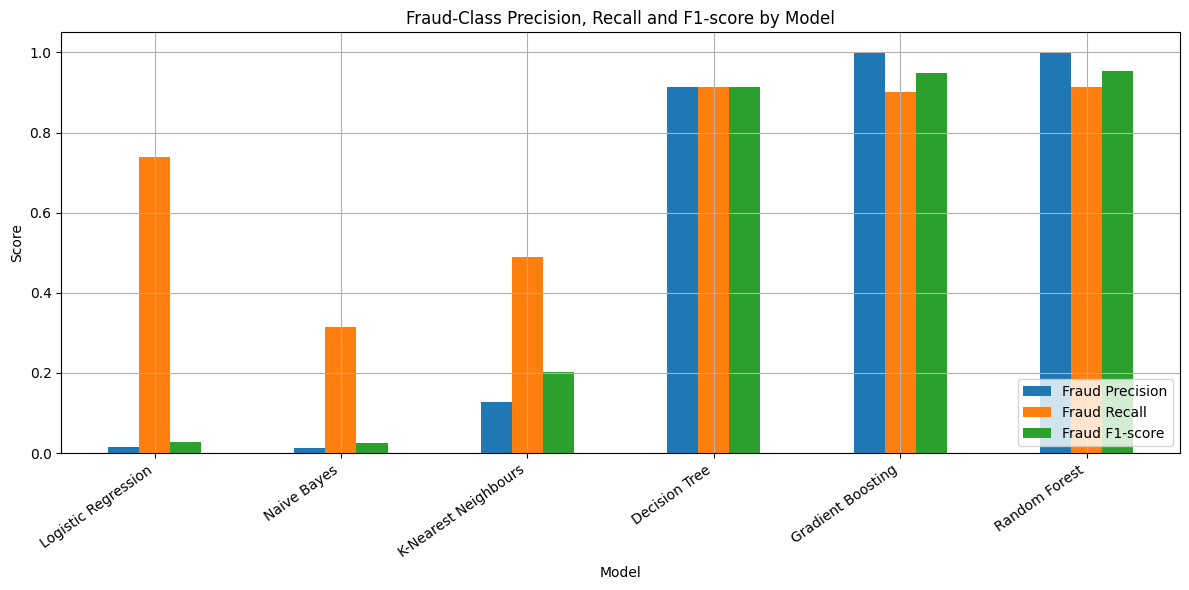

In [4]:
plot_data = results.set_index("Model")[["Fraud Precision", "Fraud Recall", "Fraud F1-score"]]

ax = plot_data.plot(kind="bar", figsize=(12, 6))
plt.title("Fraud-Class Precision, Recall and F1-score by Model")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# 5. ROC-AUC and PR-AUC chart
We compare the overall AUC scores.


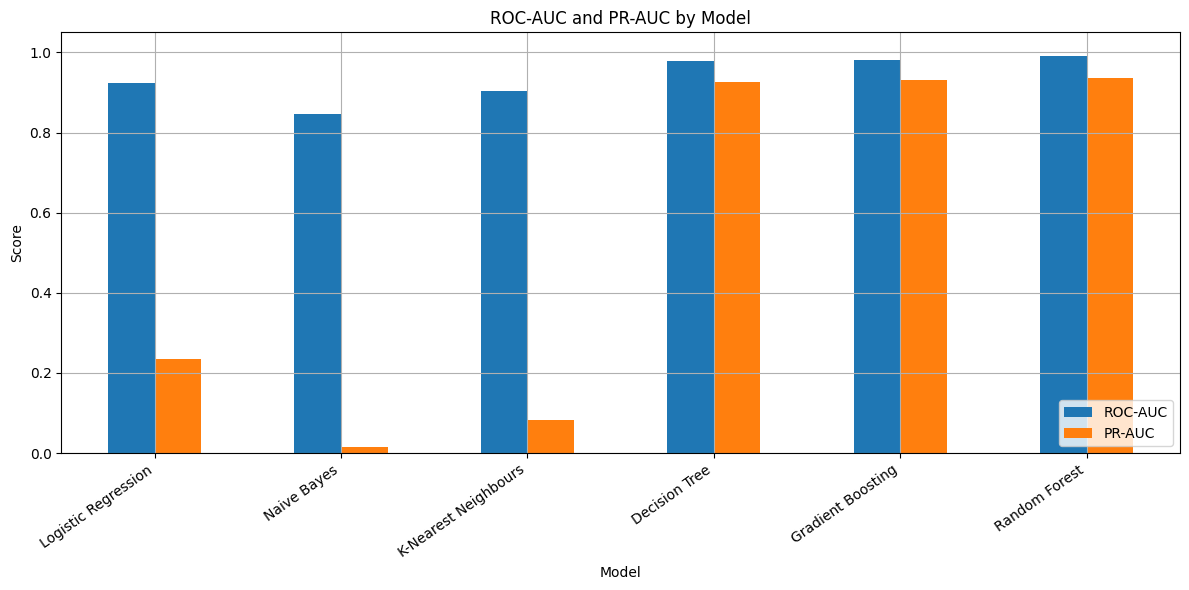

In [5]:
auc_data = results.set_index("Model")[["ROC-AUC", "PR-AUC"]]

ax = auc_data.plot(kind="bar", figsize=(12, 6))
plt.title("ROC-AUC and PR-AUC by Model")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# 6. Final recommended model check
We rerun the selected final model here as a quick check. The full model development was done in the individual notebooks, but this shows the recommended model can be trained from the processed data.


Random Forest check threshold: 0.50

Classification report (Random Forest check)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70651
           1       1.00      0.91      0.95        92

    accuracy                           1.00     70743
   macro avg       1.00      0.96      0.98     70743
weighted avg       1.00      1.00      1.00     70743

Random Forest check metrics:
Accuracy: 0.9999
Fraud Precision: 1.0000
Fraud Recall: 0.9130
Fraud F1-score: 0.9545
ROC-AUC: 0.9899
PR-AUC: 0.9357

Small differences can happen if the model settings or processed files differ from the original individual notebook run, so the final comparison table remains based on the individual notebook outputs.


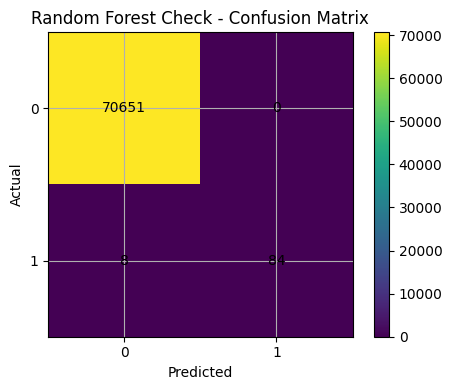

In [6]:
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

DATA_DIR = Path('../03_Processed_Data')

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').values.ravel()

rf_threshold = float(results.loc[results['Model'] == 'Random Forest', 'Threshold'].iloc[0])

rf_check_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_check_model.fit(X_train, y_train)

y_scores = rf_check_model.predict_proba(X_test)[:, 1]
y_pred = (y_scores >= rf_threshold).astype(int)

print(f'Random Forest check threshold: {rf_threshold:.2f}')
print('\nClassification report (Random Forest check)')
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title('Random Forest Check - Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

rf_check_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Fraud Precision': precision_score(y_test, y_pred, zero_division=0),
    'Fraud Recall': recall_score(y_test, y_pred, zero_division=0),
    'Fraud F1-score': f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_scores),
    'PR-AUC': average_precision_score(y_test, y_scores),
}

print('Random Forest check metrics:')
for key, value in rf_check_metrics.items():
    print(f'{key}: {value:.4f}')

rf_table = results[results['Model'] == 'Random Forest'].iloc[0]
compare_cols = ['Accuracy', 'Fraud Precision', 'Fraud Recall', 'Fraud F1-score', 'ROC-AUC', 'PR-AUC']
match_flags = [np.isclose(rf_check_metrics[col], float(rf_table[col]), atol=0.0, rtol=0.0) for col in compare_cols]

if not all(match_flags):
    print('\nSmall differences can happen if the model settings or processed files differ from the original individual notebook run, so the final comparison table remains based on the individual notebook outputs.')



Small differences can happen if the model settings or processed files differ from the original individual notebook run, so the final comparison table remains based on the individual notebook outputs.


# 7. Final model choice
We choose Random Forest because it had the strongest overall fraud F1-score, PR-AUC and practical precision/recall balance.


In [7]:
final_model = results[results["Model"] == "Random Forest"].copy()
challenger_model = results[results["Model"] == "Gradient Boosting"].copy()
interpretable_model = results[results["Model"] == "Decision Tree"].copy()

final_model


,Model,Model Type,Threshold,Accuracy,Fraud Precision,Fraud Recall,Fraud F1-score,ROC-AUC,PR-AUC,Recommendation
5,Random Forest,Bagged tree ensemble,0.5,0.9999,1.0,0.913,0.9545,0.99,0.9358,Recommended main model


> **Final model:** Random Forest  
> Random Forest was selected because it had the highest fraud F1-score, strong PR-AUC and a good balance between fraud precision and recall.

> **Model roles**  
> - Random Forest: recommended main model  
> - Gradient Boosting: strong challenger model  
> - Decision Tree: interpretable alternative  
> - KNN and Naive Bayes: not recommended because fraud precision and F1-score were too low


# 8. Random Forest evidence
These Random Forest outputs are included here because Random Forest was selected as the final recommended model.


,Metric,Value
0,True negatives,70651
1,False positives,0
2,False negatives,8
3,True positives,84
4,Fraud cases caught,84 out of 92
5,Fraud cases missed,8 out of 92


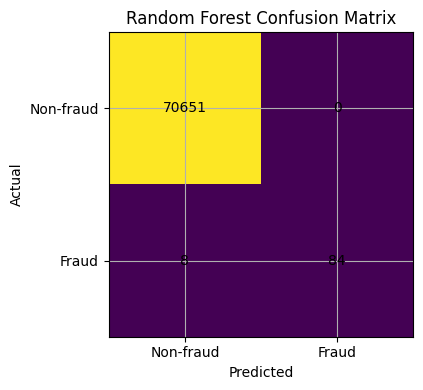

In [9]:
rf_confusion_matrix = np.array([
    [70651, 0],
    [8, 84]
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(rf_confusion_matrix)

ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-fraud", "Fraud"])
ax.set_yticklabels(["Non-fraud", "Fraud"])

for i in range(rf_confusion_matrix.shape[0]):
    for j in range(rf_confusion_matrix.shape[1]):
        ax.text(j, i, rf_confusion_matrix[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

rf_confusion_summary = pd.DataFrame({
    "Metric": [
        "True negatives",
        "False positives",
        "False negatives",
        "True positives",
        "Fraud cases caught",
        "Fraud cases missed"
    ],
    "Value": [
        rf_confusion_matrix[0, 0],
        rf_confusion_matrix[0, 1],
        rf_confusion_matrix[1, 0],
        rf_confusion_matrix[1, 1],
        f"{rf_confusion_matrix[1, 1]} out of {rf_confusion_matrix[1].sum()}",
        f"{rf_confusion_matrix[1, 0]} out of {rf_confusion_matrix[1].sum()}"
    ]
})

rf_confusion_summary


In [10]:
feature_importance = pd.DataFrame({
    "Feature": [
        "sender_balance_error",
        "amount_to_balance_ratio",
        "newbalanceOrig",
        "sender_balance_change",
        "oldbalanceDest",
        "newbalanceDest",
        "oldbalanceOrg",
        "receiver_balance_change",
        "amount",
        "receiver_balance_error",
        "step",
        "type_TRANSFER",
        "type_CASH_OUT"
    ],
    "Importance": [
        0.332235,
        0.269350,
        0.090525,
        0.074791,
        0.058425,
        0.052924,
        0.039185,
        0.025602,
        0.022821,
        0.018250,
        0.010416,
        0.003082,
        0.002395
    ]
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
0,sender_balance_error,0.332235
1,amount_to_balance_ratio,0.269350
2,newbalanceOrig,0.090525
3,sender_balance_change,0.074791
4,oldbalanceDest,0.058425
5,newbalanceDest,0.052924
6,oldbalanceOrg,0.039185
7,receiver_balance_change,0.025602
8,amount,0.022821
9,receiver_balance_error,0.018250


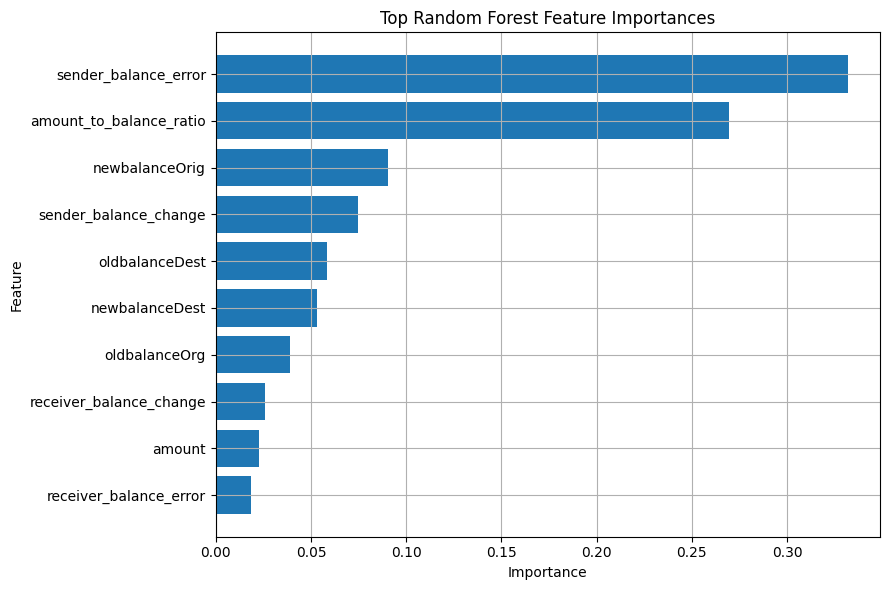

In [11]:
top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 9. Business recommendations
> **Business recommendations**  
> - Use Random Forest as the main fraud scoring model.  
> - Keep Gradient Boosting as a challenger model.  
> - Prioritise TRANSFER and CASH_OUT transactions.  
> - Use model scores to support human review before automatic blocking.  
> - Monitor sender_balance_error and amount_to_balance_ratio.  
> - Validate on real transaction data before deployment.
